# 04 — Cash overlay défensif limité

Objectif : tester une variante **mostly invested** de la stratégie actuelle, puis comparer aussi avec une version **PyPortfolioOpt classique + cash overlay**.

La stratégie de base reste :

```text
FinBERT + momentum corrigé → global_score → PyPortfolioOpt → poids actions
```

Ce notebook ajoute uniquement une couche d'exposition :

```text
poids finaux actions = poids PyPortfolioOpt × exposition_actions
cash = 1 - exposition_actions
```

On ne cherche pas à passer agressivement à `100 % cash`. On teste seulement une poche cash limitée : 10 %, 20 % ou 30 % maximum.

La nouveauté de cette version est la comparaison avec :

```text
PyPortfolioOpt classique
PyPortfolioOpt classique + cash overlay max 20 %
```

Pré-requis : avoir lancé avant ce notebook :

```bash
python -m backtesting_2.engine_pypfopt
python -m backtesting_2.analyze_results
```

Le notebook lit les CSV déjà produits dans `backtesting_2/data_output/` et `backtesting_2/results/`.


In [10]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)


def find_repo_root() -> Path:
    """Trouve la racine du repo, que le notebook soit lancé depuis la racine, backtesting_2 ou notebooks."""
    candidates = [Path.cwd(), *Path.cwd().parents]
    for p in candidates:
        if (p / "backtesting_2" / "config_backtest.py").exists():
            return p
        if p.name == "backtesting_2" and (p / "config_backtest.py").exists():
            return p.parent
    raise FileNotFoundError("Impossible de trouver la racine du repo contenant backtesting_2/config_backtest.py")

ROOT = find_repo_root()
BT = ROOT / "backtesting_2"

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from backtesting_2.config_backtest import (
    TICKERS,
    INITIAL_CAPITAL,
    DATA_OUTPUT,
    RESULTS_DIR,
    FREQUENCY,
    BACKTEST_START,
    BACKTEST_END,
    WEIGHT_BOUNDS,
    RISK_FREE_RATE,
)

print("ROOT =", ROOT)
print("TICKERS =", TICKERS)
print("Période =", BACKTEST_START, "→", BACKTEST_END)
print("WEIGHT_BOUNDS =", WEIGHT_BOUNDS)


ROOT = /Users/julio/Developer/Portfolio-Management-MODS
TICKERS = ['NKE', 'TGT', 'DIS', 'SBUX', 'TSLA']
Période = 2026-01-02 → 2026-05-29
WEIGHT_BOUNDS = (0.05, 0.4)


## 1. Chargement des résultats existants

On part des poids et rendements déjà produits par `engine_pypfopt.py`.  
Le cash overlay est donc un **post-traitement de la stratégie actuelle**, sans recalculer FinBERT et sans relancer PyPortfolioOpt.

In [11]:
prices_path = DATA_OUTPUT / "prices_backtest.csv"
returns_path = RESULTS_DIR / "portfolio_returns.csv"
weights_path = RESULTS_DIR / "weights_history.csv"
global_scores_path = DATA_OUTPUT / "daily_global_scores.csv"

required = [prices_path, returns_path, weights_path, global_scores_path]
missing = [str(p) for p in required if not p.exists()]
if missing:
    raise FileNotFoundError("Fichiers manquants. Lance d'abord engine_pypfopt.py :\n" + "\n".join(missing))

prices = pd.read_csv(prices_path, parse_dates=["date"]).set_index("date").sort_index()
returns_df = pd.read_csv(returns_path, parse_dates=["date", "next_date"]).sort_values("date")
weights_long = pd.read_csv(weights_path, parse_dates=["date"])
global_scores = pd.read_csv(global_scores_path, parse_dates=["date"])

base_returns = returns_df.set_index("date")["portfolio_return"].sort_index()
base_returns.name = "Fully invested signal"

weights_wide = (
    weights_long
    .pivot(index="date", columns="ticker", values="weight")
    .reindex(columns=TICKERS)
    .fillna(0.0)
    .sort_index()
)

scores_wide = (
    global_scores
    .pivot(index="date", columns="ticker", values="global_score")
    .reindex(columns=TICKERS)
    .fillna(0.0)
    .sort_index()
)

print("Rendements base :", base_returns.index.min().date(), "→", base_returns.index.max().date(), "|", len(base_returns), "jours")
print("Poids :", weights_wide.shape)
print("Scores :", scores_wide.shape)

display(returns_df.head())
display(weights_wide.head())
display(scores_wide.head())


Rendements base : 2026-01-02 → 2026-05-28 | 101 jours
Poids : (101, 5)
Scores : (101, 5)


,date,next_date,portfolio_return,portfolio_value,cumulative_return
0,2026-01-02,2026-01-05,0.023261,102326.0550,0.023261
1,2026-01-05,2026-01-06,-0.005202,101793.7763,0.017938
2,2026-01-06,2026-01-07,-0.009299,100847.2351,0.008472
3,2026-01-07,2026-01-08,0.018224,102685.0594,0.026851
4,2026-01-08,2026-01-09,0.007746,103480.4551,0.034805


ticker,NKE,TGT,DIS,SBUX,TSLA
date,,,,,
2026-01-02,0.05,0.4,0.10000,0.05000,0.4
2026-01-05,0.05,0.4,0.10000,0.05000,0.4
2026-01-06,0.05,0.4,0.05000,0.10000,0.4
2026-01-07,0.05,0.4,0.05000,0.10000,0.4
2026-01-08,0.05,0.4,0.09138,0.05862,0.4


ticker,NKE,TGT,DIS,SBUX,TSLA
date,,,,,
2026-01-02,-0.871608,0.630831,0.144225,-0.853272,0.483503
2026-01-05,-0.240244,0.366326,0.313455,-0.201391,-0.493102
2026-01-06,0.384673,0.766306,0.157981,0.196880,-0.245963
2026-01-07,-0.250057,0.606567,0.650396,0.681948,-0.669344
2026-01-08,0.551078,0.690552,0.336297,0.078735,-0.010280


## 2. Signal de pilotage de l'exposition actions

Deux options sont possibles :

- `weighted` : score moyen du portefeuille réellement détenu, pondéré par les poids PyPortfolioOpt.
- `mean` : score moyen simple des 5 tickers.

Par défaut, on utilise `weighted`, car la poche cash doit réagir au risque du portefeuille effectivement construit.

,weighted_global_score
count,101.000000
mean,0.198996
std,0.187763
min,-0.238644
25%,0.087570
50%,0.202941
75%,0.344560
max,0.603393


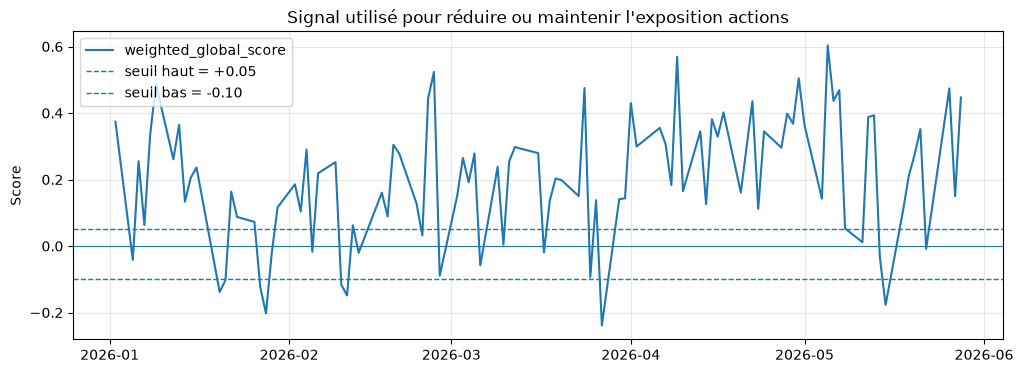

In [12]:
SIGNAL_MODE = "weighted"  # "weighted" ou "mean"


def build_overlay_signal(weights_wide: pd.DataFrame, scores_wide: pd.DataFrame, mode: str = "weighted") -> pd.Series:
    scores_aligned = scores_wide.reindex(weights_wide.index).fillna(0.0)

    if mode == "weighted":
        signal = (weights_wide * scores_aligned).sum(axis=1)
        signal.name = "weighted_global_score"
        return signal

    if mode == "mean":
        signal = scores_aligned.mean(axis=1)
        signal.name = "mean_global_score"
        return signal

    raise ValueError("mode doit être 'weighted' ou 'mean'")


overlay_signal = build_overlay_signal(weights_wide, scores_wide, SIGNAL_MODE).reindex(base_returns.index).fillna(0.0)

display(overlay_signal.describe().to_frame())

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(overlay_signal.index, overlay_signal.values, label=overlay_signal.name)
ax.axhline(0.05, linestyle="--", linewidth=1, label="seuil haut = +0.05")
ax.axhline(-0.10, linestyle="--", linewidth=1, label="seuil bas = -0.10")
ax.axhline(0.0, linewidth=0.8)
ax.set_title("Signal utilisé pour réduire ou maintenir l'exposition actions")
ax.set_ylabel("Score")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

## 3. Règle de cash overlay

Règle retenue :

```text
signal >= upper_signal  → 100 % actions
signal <= lower_signal  → exposition minimale aux actions
entre les deux          → interpolation linéaire
```

On teste trois niveaux :

```text
max cash 10 % → exposition actions minimale 90 %
max cash 20 % → exposition actions minimale 80 %
max cash 30 % → exposition actions minimale 70 %
```

Le rendement du cash est mis à `0 %` par défaut pour rester conservateur.

In [13]:
LOWER_SIGNAL = -0.10
UPPER_SIGNAL = 0.05
CASH_ANNUAL_RETURN = 0.00
MIN_EQUITY_LEVELS = [0.80]


def equity_exposure_from_signal(
    signal: pd.Series,
    min_equity: float = 0.80,
    lower: float = LOWER_SIGNAL,
    upper: float = UPPER_SIGNAL,
) -> pd.Series:
    """
    Transforme un signal en exposition actions.

    - signal >= upper : 1.00
    - signal <= lower : min_equity
    - entre lower et upper : interpolation linéaire
    """
    if not (0.0 <= min_equity <= 1.0):
        raise ValueError("min_equity doit être entre 0 et 1")
    if upper <= lower:
        raise ValueError("upper doit être strictement supérieur à lower")

    signal = pd.Series(signal).astype(float)
    scaled = ((signal - lower) / (upper - lower)).clip(0.0, 1.0)
    exposure = min_equity + scaled * (1.0 - min_equity)
    return exposure.clip(min_equity, 1.0)


def apply_cash_overlay(
    base_returns: pd.Series,
    signal: pd.Series,
    min_equity: float = 0.80,
    lower: float = LOWER_SIGNAL,
    upper: float = UPPER_SIGNAL,
    cash_annual_return: float = CASH_ANNUAL_RETURN,
    frequency: int = FREQUENCY,
) -> tuple[pd.Series, pd.Series]:
    exposure = equity_exposure_from_signal(signal, min_equity=min_equity, lower=lower, upper=upper)
    exposure = exposure.reindex(base_returns.index).fillna(1.0)

    cash_daily_return = cash_annual_return / frequency
    overlay_returns = exposure * base_returns + (1.0 - exposure) * cash_daily_return

    cash_pct = int(round((1.0 - min_equity) * 100))
    overlay_returns.name = f"Cash overlay max {cash_pct}%"
    exposure.name = f"equity_exposure_cash_max_{cash_pct}pct"
    return overlay_returns, exposure


strategies = {}
exposures = {}

for min_equity in MIN_EQUITY_LEVELS:
    rets, exp = apply_cash_overlay(base_returns, overlay_signal, min_equity=min_equity)

    # On ne garde que la variante signal-adjusted avec cash overlay max 20 %
    strategies["Signal-adjusted + cash overlay max 20%"] = rets
    exposures[rets.name] = exp

list(strategies.keys())

['Signal-adjusted + cash overlay max 20%']

## 4. Métriques de performance et benchmark classique

On utilise les mêmes métriques que `analyze_results.py` : rendement total, rendement annualisé, volatilité annualisée, Sharpe et drawdown maximum.

Cette section ajoute aussi deux séries de comparaison :

```text
PyPortfolioOpt classique
PyPortfolioOpt classique + cash overlay max 20 %
```

Le cash overlay du benchmark classique utilise le même principe que la stratégie signal-adjusted : exposition actions réduite lorsque le `global_score` pondéré du portefeuille devient faible.


In [14]:
def compute_metrics(portfolio_returns: pd.Series, label: str) -> dict:
    portfolio_returns = pd.Series(portfolio_returns).dropna().astype(float)
    n = len(portfolio_returns)

    total_return = float((1.0 + portfolio_returns).prod() - 1.0) if n else 0.0
    ann_return = float((1.0 + total_return) ** (FREQUENCY / n) - 1.0) if n else 0.0
    ann_vol = float(portfolio_returns.std(ddof=1) * np.sqrt(FREQUENCY)) if n > 1 else 0.0
    sharpe = (ann_return - 0.02) / ann_vol if ann_vol > 1e-10 else 0.0

    cum = (1.0 + portfolio_returns).cumprod()
    drawdown = cum / cum.cummax() - 1.0 if len(cum) else pd.Series(dtype=float)
    max_dd = float(drawdown.min()) if len(drawdown) else 0.0

    return {
        "strategie": label,
        "rendement_total": round(total_return, 4),
        "rendement_annualise": round(ann_return, 4),
        "volatilite_annualisee": round(ann_vol, 4),
        "sharpe_ratio": round(float(sharpe), 4),
        "max_drawdown": round(max_dd, 4),
        "n_jours": int(n),
    }


def benchmark_equal_weight_from_prices(prices: pd.DataFrame, returns_df: pd.DataFrame, tickers: list[str]) -> pd.Series:
    rows = []
    for _, row in returns_df.iterrows():
        d = row["date"]
        nd = row["next_date"]
        if d not in prices.index or nd not in prices.index:
            continue
        asset_ret = (prices.loc[nd, tickers] / prices.loc[d, tickers] - 1.0).astype(float)
        rows.append({"date": d, "equal_weight_return": float(asset_ret.mean())})
    return pd.DataFrame(rows).set_index("date")["equal_weight_return"].sort_index()


def benchmark_pypfopt_classic_from_prices(
    prices: pd.DataFrame,
    returns_df: pd.DataFrame,
    tickers: list[str],
) -> tuple[pd.Series, dict[str, float]]:
    """
    Benchmark PyPortfolioOpt classique, sans signal.

    Pour rester comparable au moteur, on :
    - entraîne les poids sur les prix disponibles jusqu'au début du backtest ;
    - applique ces poids aux rendements J → J+1 du même calendrier que portfolio_returns.csv.
    """
    from pypfopt.expected_returns import mean_historical_return
    from pypfopt.risk_models import CovarianceShrinkage
    from pypfopt.efficient_frontier import EfficientFrontier

    start = pd.Timestamp(BACKTEST_START)
    train = prices.loc[:start].reindex(columns=tickers).ffill().dropna(how="all")

    if len(train) < 30:
        classic_weights = {ticker: 1.0 / len(tickers) for ticker in tickers}
        method = "equal-weight fallback"
    else:
        mu = mean_historical_return(train, frequency=FREQUENCY)
        S = CovarianceShrinkage(train, frequency=FREQUENCY).ledoit_wolf()

        try:
            ef = EfficientFrontier(mu, S, weight_bounds=WEIGHT_BOUNDS)
            ef.max_sharpe(risk_free_rate=RISK_FREE_RATE)
            classic_weights = dict(ef.clean_weights())
            method = "max_sharpe"
        except Exception as exc_max_sharpe:
            try:
                ef = EfficientFrontier(mu, S, weight_bounds=WEIGHT_BOUNDS)
                ef.min_volatility()
                classic_weights = dict(ef.clean_weights())
                method = f"min_volatility fallback après max_sharpe: {exc_max_sharpe}"
            except Exception as exc_min_vol:
                classic_weights = {ticker: 1.0 / len(tickers) for ticker in tickers}
                method = f"equal-weight fallback après erreur: {exc_min_vol}"

    classic_weights = {ticker: float(classic_weights.get(ticker, 0.0)) for ticker in tickers}
    total = sum(classic_weights.values())
    if total <= 0:
        classic_weights = {ticker: 1.0 / len(tickers) for ticker in tickers}
    else:
        classic_weights = {ticker: classic_weights[ticker] / total for ticker in tickers}

    rows = []
    for _, row in returns_df.iterrows():
        d = row["date"]
        nd = row["next_date"]
        if d not in prices.index or nd not in prices.index:
            continue
        asset_ret = (prices.loc[nd, tickers] / prices.loc[d, tickers] - 1.0).astype(float)
        pf_ret = sum(classic_weights[ticker] * float(asset_ret[ticker]) for ticker in tickers)
        rows.append({"date": d, "pypfopt_classic_return": pf_ret})

    classic_returns = pd.DataFrame(rows).set_index("date")["pypfopt_classic_return"].sort_index()
    classic_returns.name = "PyPortfolioOpt classique"

    print("Méthode PyPortfolioOpt classique :", method)
    print("Poids PyPortfolioOpt classique :")
    display(pd.Series(classic_weights, name="weight").to_frame().T)

    return classic_returns, classic_weights


comparison_series = dict(strategies)

# Benchmark equal-weight calculé depuis les prix existants, sans requête externe.
eq_returns = benchmark_equal_weight_from_prices(prices, returns_df, TICKERS).reindex(base_returns.index).fillna(0.0)
eq_returns.name = "Equal-weight"

# Benchmark PyPortfolioOpt classique, puis même cash overlay limité à 20 %.
classic_returns, classic_weights = benchmark_pypfopt_classic_from_prices(prices, returns_df, TICKERS)
classic_returns = classic_returns.reindex(base_returns.index).fillna(0.0)

classic_weights_s = pd.Series(classic_weights).reindex(TICKERS).fillna(0.0)
classic_overlay_signal = (scores_wide.reindex(base_returns.index).fillna(0.0) * classic_weights_s).sum(axis=1)
classic_overlay_signal.name = "classic_weighted_global_score"

classic_cash20_returns, classic_cash20_exposure = apply_cash_overlay(
    classic_returns,
    classic_overlay_signal,
    min_equity=0.80,
)
classic_cash20_returns.name = "PyPortfolioOpt classique + cash overlay max 20%"
classic_cash20_exposure.name = "classic_equity_exposure_cash_max_20pct"

comparison_series["PyPortfolioOpt classique"] = classic_returns
comparison_series[classic_cash20_returns.name] = classic_cash20_returns
comparison_series["Equal-weight"] = eq_returns
exposures[classic_cash20_returns.name] = classic_cash20_exposure

metrics_df = pd.DataFrame([
    compute_metrics(rets, label)
    for label, rets in comparison_series.items()
]).sort_values("sharpe_ratio", ascending=False)

metrics_df


Méthode PyPortfolioOpt classique : max_sharpe
Poids PyPortfolioOpt classique :


,NKE,TGT,DIS,SBUX,TSLA
weight,0.05,0.4,0.07146,0.07854,0.4


,strategie,rendement_total,rendement_annualise,volatilite_annualisee,sharpe_ratio,max_drawdown,n_jours
0,Signal-adjusted + cash overlay max 20%,0.1374,0.3788,0.2205,1.6270,-0.0721,101
2,PyPortfolioOpt classique + cash overlay max 20%,0.1184,0.3221,0.2135,1.4152,-0.0770,101
1,PyPortfolioOpt classique,0.1113,0.3011,0.2209,1.2725,-0.0890,101
3,Equal-weight,0.0203,0.0513,0.2019,0.1552,-0.1283,101


## 5. Graphique des valeurs cumulées

Ce graphique montre si le cash overlay améliore la trajectoire, en particulier pendant les phases de baisse.

Il inclut maintenant aussi :

```text
PyPortfolioOpt classique
PyPortfolioOpt classique + cash overlay max 20 %
```


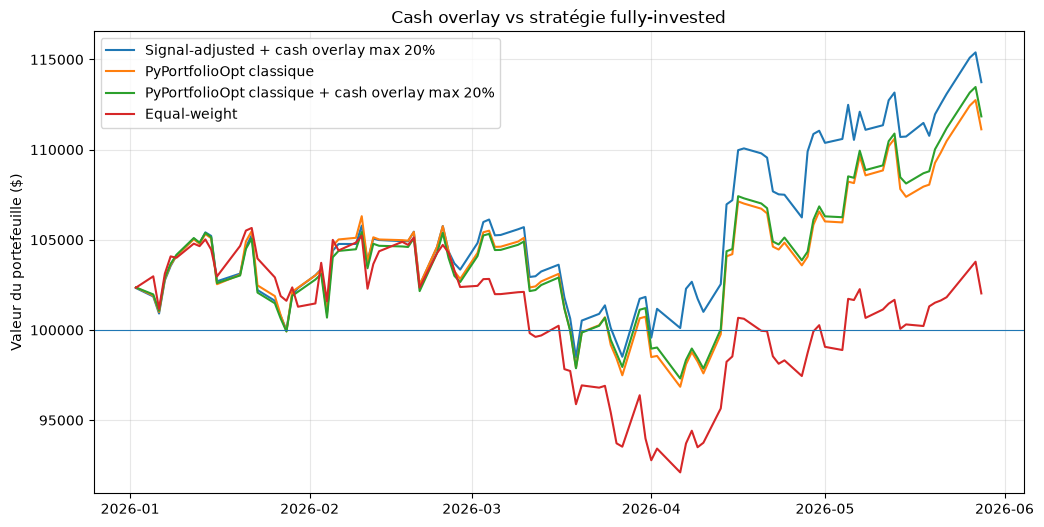

In [15]:
fig, ax = plt.subplots(figsize=(12, 6))

for label, rets in comparison_series.items():
    cum_value = (1.0 + rets.reindex(base_returns.index).fillna(0.0)).cumprod() * INITIAL_CAPITAL
    ax.plot(cum_value.index, cum_value.values, label=label)

ax.axhline(INITIAL_CAPITAL, linewidth=0.8)
ax.set_title("Cash overlay vs stratégie fully-invested")
ax.set_ylabel("Valeur du portefeuille ($)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

## 6. Exposition actions dans le temps

On vérifie que la stratégie reste bien **majoritairement investie**.  
Même dans la variante la plus défensive, l'exposition actions ne descend pas sous 70 %.

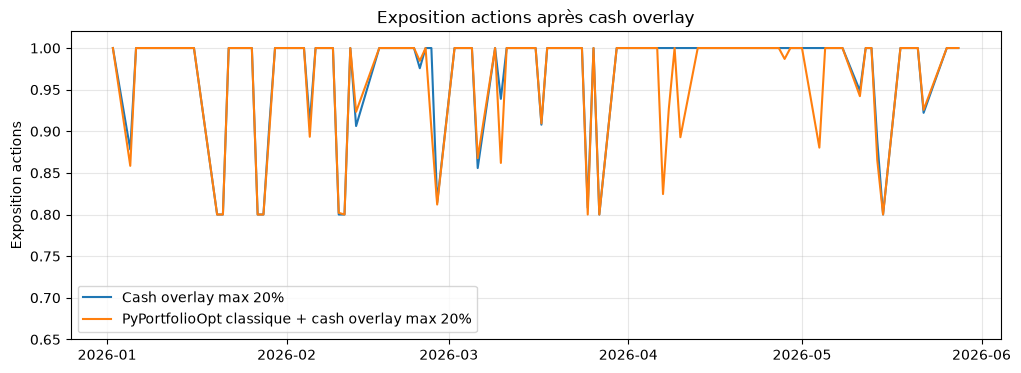

,Cash overlay max 20%,PyPortfolioOpt classique + cash overlay max 20%
count,101.000000,101.000000
mean,0.970898,0.963951
std,0.063324,0.067407
min,0.800000,0.800000
25%,1.000000,0.984562
50%,1.000000,1.000000
75%,1.000000,1.000000
max,1.000000,1.000000


In [16]:
fig, ax = plt.subplots(figsize=(12, 4))

for label, exp in exposures.items():
    ax.plot(exp.index, exp.values, label=label)

ax.set_ylim(0.65, 1.02)
ax.set_title("Exposition actions après cash overlay")
ax.set_ylabel("Exposition actions")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

exposure_summary = pd.DataFrame({label: exp.describe() for label, exp in exposures.items()})
exposure_summary

## 7. Poids finaux avec cash — variante principale 20 % max

La variante centrale est `Cash overlay max 20%` : elle autorise du cash, mais garde au moins 80 % du portefeuille en actions.

In [17]:
SELECTED_CASH_MAX = 20
SELECTED_LABEL = f"Cash overlay max {SELECTED_CASH_MAX}%"
CLASSIC_SELECTED_LABEL = f"PyPortfolioOpt classique + cash overlay max {SELECTED_CASH_MAX}%"

if SELECTED_LABEL not in exposures:
    raise KeyError(f"{SELECTED_LABEL} absent. Vérifie MIN_EQUITY_LEVELS.")

selected_exposure = exposures[SELECTED_LABEL]

selected_weights = weights_long.copy()
selected_weights["equity_exposure"] = selected_weights["date"].map(selected_exposure)
selected_weights["equity_exposure"] = selected_weights["equity_exposure"].fillna(1.0)
selected_weights["weight"] = selected_weights["weight"] * selected_weights["equity_exposure"]
selected_weights = selected_weights[["date", "ticker", "weight"]]

cash_rows = pd.DataFrame({
    "date": selected_exposure.index,
    "ticker": "CASH",
    "weight": 1.0 - selected_exposure.values,
})

selected_weights_with_cash = pd.concat([selected_weights, cash_rows], ignore_index=True).sort_values(["date", "ticker"])

# Poids finaux du benchmark PyPortfolioOpt classique + cash overlay max 20 %
classic_selected_exposure = exposures.get(CLASSIC_SELECTED_LABEL)
classic_weights_with_cash = pd.DataFrame()

if classic_selected_exposure is not None:
    classic_weight_rows = []
    for date, exposure in classic_selected_exposure.items():
        for ticker in TICKERS:
            classic_weight_rows.append({
                "date": date,
                "ticker": ticker,
                "weight": classic_weights.get(ticker, 0.0) * exposure,
            })
        classic_weight_rows.append({
            "date": date,
            "ticker": "CASH",
            "weight": 1.0 - exposure,
        })
    classic_weights_with_cash = pd.DataFrame(classic_weight_rows).sort_values(["date", "ticker"])

display(selected_weights_with_cash.head(15))
print("Somme des poids signal + cash, premières dates :")
display(selected_weights_with_cash.groupby("date")["weight"].sum().head())

if not classic_weights_with_cash.empty:
    print("Somme des poids PyPortfolioOpt classique + cash, premières dates :")
    display(classic_weights_with_cash.groupby("date")["weight"].sum().head())


,date,ticker,weight
505,2026-01-02,CASH,0.000000
2,2026-01-02,DIS,0.100000
0,2026-01-02,NKE,0.050000
3,2026-01-02,SBUX,0.050000
1,2026-01-02,TGT,0.400000
4,2026-01-02,TSLA,0.400000
506,2026-01-05,CASH,0.121929
7,2026-01-05,DIS,0.087807
5,2026-01-05,NKE,0.043904
8,2026-01-05,SBUX,0.043904


Somme des poids signal + cash, premières dates :


date
2026-01-02    1.0
2026-01-05    1.0
2026-01-06    1.0
2026-01-07    1.0
2026-01-08    1.0
Name: weight, dtype: float64

Somme des poids PyPortfolioOpt classique + cash, premières dates :


date
2026-01-02    1.0
2026-01-05    1.0
2026-01-06    1.0
2026-01-07    1.0
2026-01-08    1.0
Name: weight, dtype: float64

## 8. Export des résultats

Le notebook exporte :

```text
backtesting_2/results/cash_overlay_comparison.csv
backtesting_2/results/cash_overlay_returns.csv
backtesting_2/results/weights_cash_overlay_20.csv
backtesting_2/results/weights_classic_cash_overlay_20.csv
backtesting_2/results/cash_overlay_chart.png
```

Ces fichiers peuvent servir pour le rapport ou pour intégrer ensuite la logique dans `engine_pypfopt.py`.


In [18]:
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Table de métriques
comparison_path = RESULTS_DIR / "cash_overlay_comparison.csv"
metrics_df.to_csv(comparison_path, index=False)

# Rendements journaliers
returns_overlay = pd.DataFrame({
    label: rets.reindex(base_returns.index).fillna(0.0)
    for label, rets in comparison_series.items()
})
returns_overlay.index.name = "date"
returns_path = RESULTS_DIR / "cash_overlay_returns.csv"
returns_overlay.to_csv(returns_path)

# Poids avec cash pour la variante signal-adjusted 20 %
weights_cash_path = RESULTS_DIR / "weights_cash_overlay_20.csv"
selected_weights_with_cash.to_csv(weights_cash_path, index=False)

# Poids avec cash pour PyPortfolioOpt classique + cash overlay 20 %
classic_weights_cash_path = RESULTS_DIR / "weights_classic_cash_overlay_20.csv"
if not classic_weights_with_cash.empty:
    classic_weights_with_cash.to_csv(classic_weights_cash_path, index=False)

# Graphique sauvegardé
fig, ax = plt.subplots(figsize=(12, 6))
for label, rets in comparison_series.items():
    cum_value = (1.0 + rets.reindex(base_returns.index).fillna(0.0)).cumprod() * INITIAL_CAPITAL
    ax.plot(cum_value.index, cum_value.values, label=label)
ax.axhline(INITIAL_CAPITAL, linewidth=0.8)
ax.set_title("Cash overlay vs stratégies fully-invested")
ax.set_ylabel("Valeur du portefeuille ($)")
ax.grid(True, alpha=0.3)
ax.legend()
chart_path = RESULTS_DIR / "cash_overlay_chart.png"
plt.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.close()

print("Exports créés :")
print("-", comparison_path)
print("-", returns_path)
print("-", weights_cash_path)
if not classic_weights_with_cash.empty:
    print("-", classic_weights_cash_path)
print("-", chart_path)


Exports créés :
- /Users/julio/Developer/Portfolio-Management-MODS/backtesting_2/results/cash_overlay_comparison.csv
- /Users/julio/Developer/Portfolio-Management-MODS/backtesting_2/results/cash_overlay_returns.csv
- /Users/julio/Developer/Portfolio-Management-MODS/backtesting_2/results/weights_cash_overlay_20.csv
- /Users/julio/Developer/Portfolio-Management-MODS/backtesting_2/results/weights_classic_cash_overlay_20.csv
- /Users/julio/Developer/Portfolio-Management-MODS/backtesting_2/results/cash_overlay_chart.png


## 9. Interprétation attendue

À commenter dans le rapport :

- Si le cash overlay augmente le Sharpe et baisse le drawdown, il apporte une amélioration défensive.
- Si le rendement augmente aussi, cela signifie qu'il évite certaines périodes de baisse sans trop réduire l'exposition pendant les hausses.
- Si le rendement baisse mais le drawdown baisse fortement, la stratégie peut être défendable comme version plus prudente.
- Si le cash overlay ne change presque rien, cela signifie que les signaux sont rarement suffisamment négatifs pour déclencher la poche cash.

Comparaison spécifique à regarder :

```text
Signal-adjusted PyPortfolioOpt + cash overlay max 20 %
vs
PyPortfolioOpt classique + cash overlay max 20 %
```

Cette comparaison permet d'isoler deux effets :

```text
1. effet du signal sur la sélection / pondération des actions
2. effet du cash overlay sur l'exposition globale actions
```

Version recommandée par défaut :

```text
Cash overlay max 20 %
Exposition actions minimale 80 %
Signal de pilotage : global_score pondéré par les poids du portefeuille
```

Ce notebook est volontairement un prototype. Si les résultats sont robustes, la logique pourra ensuite être intégrée directement dans `engine_pypfopt.py`.
